### EMEKA UCHE - Data Analyst Takehome Test (Zipline Systems Engineering)


### PART 1

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [29]:
df = pd.read_excel('Zipline_Data_Sample.xlsx', sheet_name=0)

## EXPLORATORY DATA ANALYSIS

In [33]:
df.head()

,flight_id,asset_id,metro,takeoff_time_utc,estimated_delivery_time_utc,actual_delivery_time_utc,docking_time_utc,dock_id,takeoff_time_of_day,flight_duration_s,ground_based_distance_m,customer_name,delivery_outcome,delivery_failure_reason
0,P2F_65082A01F65D67DC,p2-zip-222,Nest XYZ,2025-01-01 06:59:01.474,2025-01-01 07:02:55.810,2025-01-01 07:04:17.137,2025-01-01 07:05:32.034,p2-dock-94,night,391,3159.2,customer_p,SUCCESS,NaN
1,P2F_6508313D92216639,p2-zip-235,Nest XYZ,2025-01-01 07:30:37.840,2025-01-01 07:33:05.777,2025-01-01 07:34:13.640,2025-01-01 07:34:44.401,p2-dock-88,night,247,274.6,customer_t,SUCCESS,NaN
2,P2F_65082C17E0ACE6B0,p2-zip-238,Nest XYZ,2025-01-01 07:08:21.641,2025-01-01 07:14:15.066,2025-01-01 07:16:23.302,2025-01-01 07:18:10.682,p2-dock-62,night,589,6937.8,customer_t,SUCCESS,NaN
3,P2F_6508214B02769470,p2-zip-224,Nest XYZ,2025-01-01 06:20:56.698,2025-01-01 06:24:45.226,NaT,2025-01-01 06:27:17.577,p2-dock-57,night,381,3148.9,customer_q,FAILURE,Obstacle Detected
4,P2F_65082DED20BC6AD2,p2-zip-237,Nest XYZ,2025-01-01 07:16:40.315,2025-01-01 07:21:45.786,2025-01-01 07:21:57.182,2025-01-01 07:25:09.434,p2-dock-47,night,509,4943.5,customer_p,SUCCESS,NaN


In [35]:
df.isnull().sum()

flight_id                         0
asset_id                          0
metro                           116
takeoff_time_utc                  0
estimated_delivery_time_utc       0
actual_delivery_time_utc        305
docking_time_utc                  0
dock_id                         135
takeoff_time_of_day             135
flight_duration_s                 0
ground_based_distance_m         124
customer_name                   116
delivery_outcome                  0
delivery_failure_reason        2750
dtype: int64

In [37]:
df.describe()

,takeoff_time_utc,estimated_delivery_time_utc,actual_delivery_time_utc,docking_time_utc,flight_duration_s,ground_based_distance_m
count,3055,3055,2750,3055,3055.000000,2.931000e+03
mean,2025-01-16 23:45:18.392685568,2025-01-16 23:48:55.236855296,2025-01-17 01:23:19.828031232,2025-01-14 14:28:31.878284288,556.658265,3.304629e+03
min,2025-01-01 00:02:01.626000,2025-01-01 00:07:02.297000,2025-01-01 00:07:46.367000,2005-01-04 19:57:39,1.000000,3.000000e+00
25%,2025-01-09 07:16:23.689499904,2025-01-09 07:20:45.037499904,2025-01-09 07:21:49.616000,2025-01-09 07:23:39.269499904,260.000000,3.877500e+02
50%,2025-01-17 02:18:29.516999936,2025-01-17 02:22:56.276999936,2025-01-17 02:41:42.471500032,2025-01-17 02:25:54.116999936,382.000000,2.372900e+03
75%,2025-01-24 18:21:58.611500032,2025-01-24 18:25:45.831500032,2025-01-24 19:05:57.914499840,2025-01-24 18:28:17.312000,500.000000,3.618200e+03
max,2025-01-30 23:50:09.490000,2025-01-30 23:52:47.674000,2025-01-30 23:54:01.902000,2025-01-31 00:04:33.131000,510026.000000,3.176000e+06
std,NaN,NaN,NaN,NaN,9222.627549,5.865713e+04


## DATA CLEANING & TRANSFORMATION

In [41]:
date_cols = [
    'takeoff_time_utc',
    'estimated_delivery_time_utc',
    'actual_delivery_time_utc',
    'docking_time_utc'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

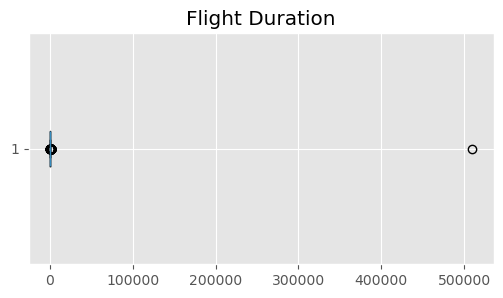

In [43]:
plt.figure(figsize=(6,3))
plt.boxplot(df['flight_duration_s'], vert=False)
plt.title('Flight Duration')
plt.show()

In [45]:
df.nlargest(5, 'flight_duration_s')

,flight_id,asset_id,metro,takeoff_time_utc,estimated_delivery_time_utc,actual_delivery_time_utc,docking_time_utc,dock_id,takeoff_time_of_day,flight_duration_s,ground_based_distance_m,customer_name,delivery_outcome,delivery_failure_reason
100,P2F_650A18C1B12B20BC,p2-zip-231,Nest 0,2025-01-02 19:00:42.861,2025-01-02 19:05:52.485,2025-01-02 19:06:56.870,2025-01-02 19:09:18.901,p2-dock-64,day,510026,3563.2,customer_f,SUCCESS,NaN
934,P2F_65157F62D418EF9F,p2-zip-249,Nest W,2025-01-11 15:32:43.696,2025-01-11 15:37:49.192,2025-01-11 15:38:11.383,2025-01-11 15:51:12.856,p2-dock-102,low sun angle,1109,3507.4,customer_k,SUCCESS,NaN
910,P2F_6515881DC38449B9,p2-zip-201,Nest W,2025-01-11 16:10:52.710,2025-01-11 16:15:56.382,2025-01-11 16:16:17.605,2025-01-11 16:29:18.830,p2-dock-105,day,1106,3497.5,customer_k,SUCCESS,NaN
807,P2F_65157E90B35827B8,p2-zip-256,Nest W,2025-01-11 15:28:48.246,2025-01-11 15:33:50.550,2025-01-11 15:36:15.786,2025-01-11 15:47:12.086,p2-dock-107,low sun angle,1104,3509.8,customer_l,SUCCESS,NaN
834,P2F_65158535DF428EA2,p2-zip-256,Nest W,2025-01-11 15:57:50.086,2025-01-11 16:02:50.902,2025-01-11 16:03:55.950,2025-01-11 16:16:11.446,p2-dock-107,day,1101,3469.0,customer_k,SUCCESS,NaN


In [101]:
mask = df['flight_duration_s'] == df['flight_duration_s'].max()

corrected_duration = (
    df.loc[mask, 'docking_time_utc'] -
    df.loc[mask, 'takeoff_time_utc']
).dt.total_seconds()

df["flight_duration_s"] = df["flight_duration_s"].astype(float)

df.loc[mask, "flight_duration_s"] = corrected_duration

In [103]:
df.describe()

,takeoff_time_utc,estimated_delivery_time_utc,actual_delivery_time_utc,docking_time_utc,flight_duration_s,ground_based_distance_m,delivery_delay_s
count,3054,3054,2749,3054,3054.000000,2930.000000,2749.000000
mean,2025-01-16 23:52:45.735123968,2025-01-16 23:56:22.574580224,2025-01-17 01:31:38.846902272,2025-01-16 23:59:15.621490688,389.880878,2221.797645,52.840669
min,2025-01-01 00:02:01.626000,2025-01-01 00:07:02.297000,2025-01-01 00:07:46.367000,2025-01-01 00:10:22.745000,1.000000,3.000000,0.000000
25%,2025-01-09 07:24:15.438749952,2025-01-09 07:27:49.416249856,2025-01-09 07:22:29.942000128,2025-01-09 07:30:30.882999808,260.000000,387.575000,19.000000
50%,2025-01-17 02:19:38.396999936,2025-01-17 02:23:39.986999808,2025-01-17 02:54:37.375000064,2025-01-17 02:25:59.442999808,382.000000,2369.000000,46.000000
75%,2025-01-24 18:22:17.046249984,2025-01-24 18:26:09.636249856,2025-01-24 19:08:28.712999936,2025-01-24 18:28:44.696999936,500.000000,3618.050000,77.000000
max,2025-01-30 23:50:09.490000,2025-01-30 23:52:47.674000,2025-01-30 23:54:01.902000,2025-01-31 00:04:33.131000,1109.160000,9990.300000,181.000000
std,NaN,NaN,NaN,NaN,197.977983,1998.487590,40.367887


In [51]:
cask = df['docking_time_utc'] == df['docking_time_utc'].min()

corrected_docking_time = (
    df.loc[cask, 'takeoff_time_utc'] +
    pd.to_timedelta(df.loc[cask, 'flight_duration_s'], unit = 's')
)

df.loc[cask, 'docking_time_utc'] = corrected_docking_time

In [53]:
df['delivery_delay_s'] = df['actual_delivery_time_utc'] - df['estimated_delivery_time_utc']

In [55]:
df['delivery_delay_s'] = df['delivery_delay_s'].dt.seconds

In [57]:
df.nlargest(5, 'ground_based_distance_m')

,flight_id,asset_id,metro,takeoff_time_utc,estimated_delivery_time_utc,actual_delivery_time_utc,docking_time_utc,dock_id,takeoff_time_of_day,flight_duration_s,ground_based_distance_m,customer_name,delivery_outcome,delivery_failure_reason,delivery_delay_s
31,P2F_6508048DDE584C07,p2-zip-245,Nest XYZ,2025-01-01 04:15:34.586,2025-01-01 04:19:25.826,2025-01-01 04:19:56.952,2025-01-01 04:21:59.986,p2-dock-96,night,385.0,3176000.2,customer_q,SUCCESS,NaN,31.0
615,P2F_650F8253BF6E75FA,p2-zip-239,Nest XYZ,2025-01-06 23:54:44.341,2025-01-07 00:01:32.173,2025-01-07 00:02:44.172,2025-01-07 00:06:04.061,p2-dock-97,day,680.0,9990.3,customer_p,SUCCESS,NaN,71.0
88,P2F_650816879128B1AC,p2-zip-239,Nest XYZ,2025-01-01 05:33:54.605,2025-01-01 05:41:27.245,2025-01-01 05:42:01.263,2025-01-01 05:46:29.005,p2-dock-97,night,755.0,7104.1,customer_p,SUCCESS,NaN,34.0
261,P2F_650BB48508D82AB5,p2-zip-226,Nest XYZ,2025-01-04 01:00:10.837,2025-01-04 01:06:38.293,2025-01-04 01:07:48.678,2025-01-04 01:10:56.596,p2-dock-33,low sun angle,646.0,7087.1,customer_s,SUCCESS,NaN,70.0
286,P2F_650CB8CE251A7471,p2-zip-148,Nest XYZ,2025-01-04 19:57:49.342,2025-01-04 20:04:31.917,2025-01-04 20:05:40.803,2025-01-04 20:09:00.301,p2-dock-90,day,671.0,7057.4,customer_t,SUCCESS,NaN,68.0


In [59]:
max_idx = df['ground_based_distance_m'].idxmax()
df = df.drop(max_idx)

In [61]:
df['ground_based_distance_m'].max()

9990.3

In [63]:
df['success'] = df['delivery_outcome'] == 'SUCCESS'

## COMPUTING METRICS

In [67]:
total_flights = len(df)
print(total_flights)

3054


In [69]:
successful = df['success'].sum()
failed = total_flights - successful

print(successful)
print(failed)

2749
305


In [71]:
success_rate = successful / total_flights * 100

print(f"{success_rate:.2f}%")

90.01%


In [73]:
avg_duration = df['flight_duration_s'].mean()

print(avg_duration)

389.88082514734776


In [75]:
avg_delay = df['delivery_delay_s'].mean()

print(avg_delay)

52.840669334303385


## CHARTS

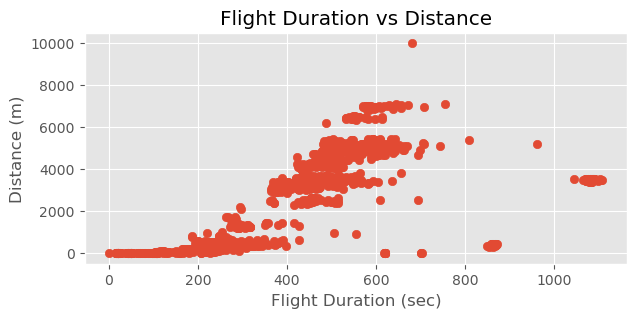

In [79]:
plt.figure(figsize=(7,3))

plt.scatter(
    df.loc[df['ground_based_distance_m'].notna(), 'flight_duration_s'],
    df.loc[df['ground_based_distance_m'].notna(), 'ground_based_distance_m'],
)

plt.xlabel('Flight Duration (sec)')
plt.ylabel('Distance (m)')

plt.title('Flight Duration vs Distance')

#plt.savefig('flight duration vs distance.png', dpi=300, bbox_inches='tight')

plt.show()

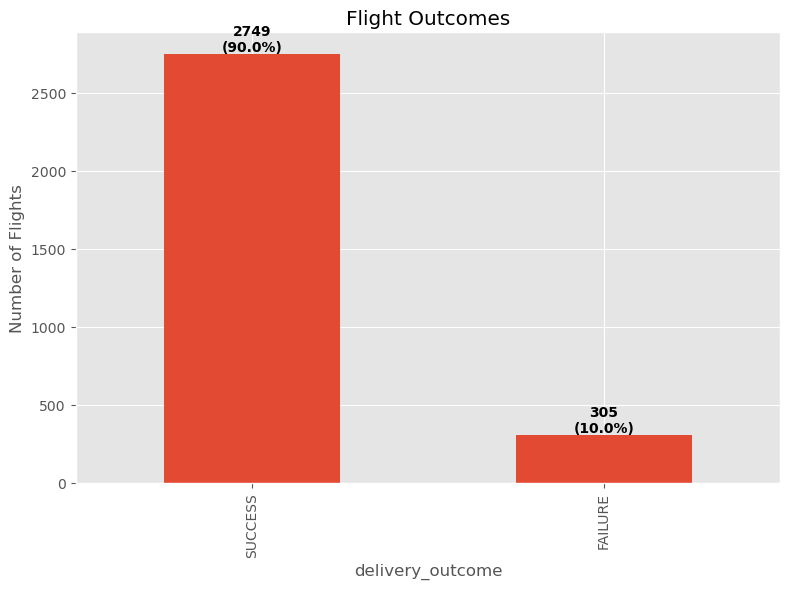

In [81]:
counts = df['delivery_outcome'].value_counts()

ax = counts.plot(
    kind='bar',
    figsize=(8,6),
    title='Flight Outcomes'
)

ax.set_ylabel('Number of Flights')

for i, v in enumerate(counts):
    ax.text(i, v, f'{v}\n({v/counts.sum():.1%})',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
#plt.savefig('flight_outcomes.png', dpi=300, bbox_inches='tight')
plt.show()

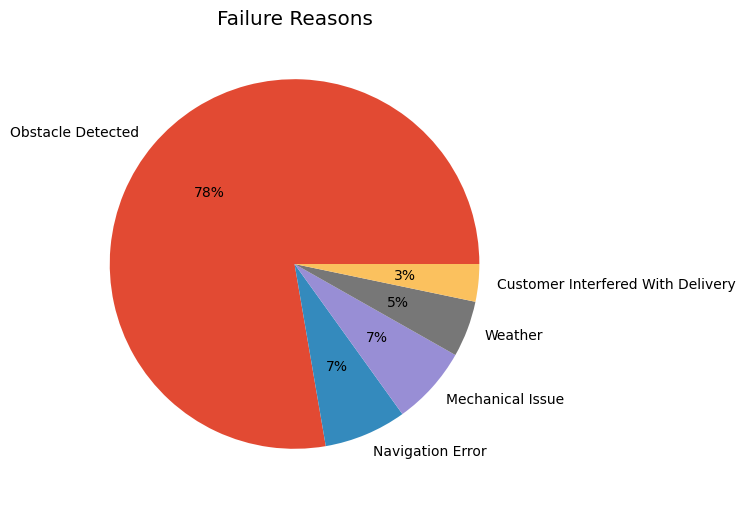

In [83]:
failures = (
    df[df['delivery_outcome']=='FAILURE']
    ['delivery_failure_reason']
    .value_counts()
)

plt.figure(figsize=(6,6))
failures.plot(kind='pie', autopct='%1.0f%%')

plt.ylabel('')
plt.title('Failure Reasons')
#plt.savefig('failure reasons.png', dpi=300, bbox_inches='tight')

plt.show()

In [85]:
df.to_csv('output.csv', index=False)

In [87]:
successful_df = df[df['delivery_outcome'] == 'SUCCESS'].copy()

In [89]:
bins = [-1, 5, 10, 20, 30, 60, 120, 300, 600, float('inf')]

labels = [
    "0-5 sec",
    "5-10 sec",
    "10-20 sec",
    "20-30 sec",
    "30-60 sec",
    "1-2 min",
    "2-5 min",
    "5-10 min",
    ">10 min"
]

In [91]:
successful_df['delay_band'] = pd.cut(
    successful_df['delivery_delay_s'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [93]:
delay_counts = (
    successful_df['delay_band']
    .value_counts(sort=False)
)

delay_pct = (
    successful_df['delay_band']
    .value_counts(sort=False, normalize=True)
    * 100
)

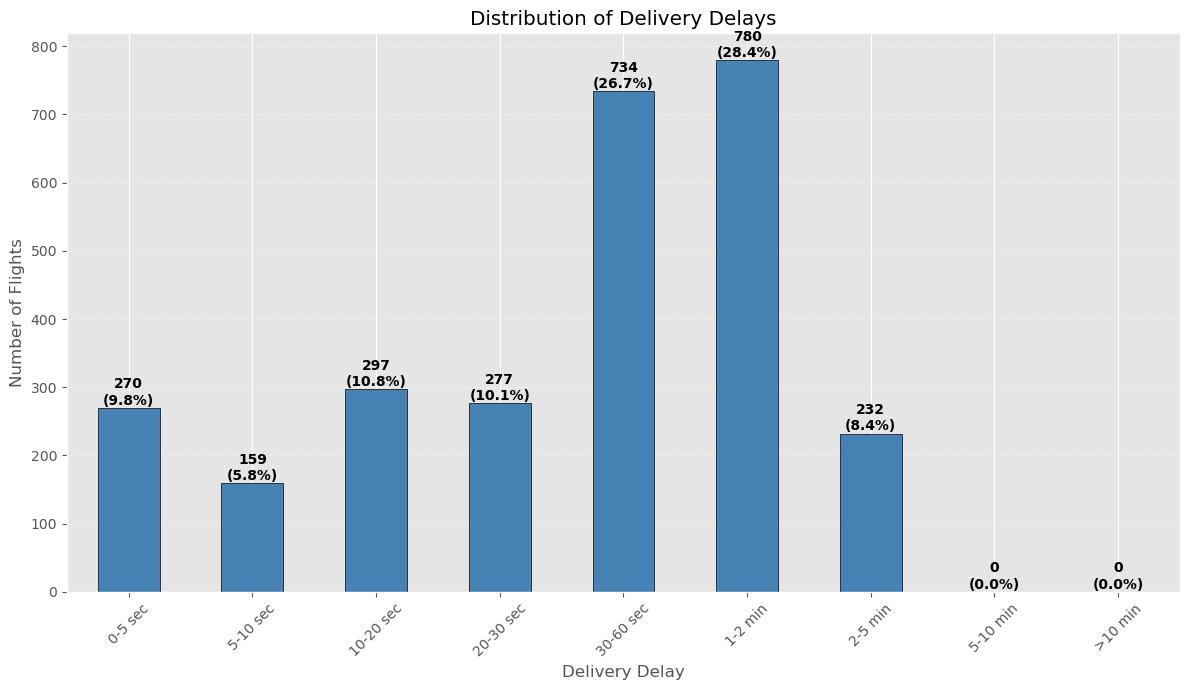

In [95]:
plt.figure(figsize=(12, 7))

ax = delay_counts.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.title('Distribution of Delivery Delays')
plt.xlabel('Delivery Delay')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)


for i, (count, pct) in enumerate(zip(delay_counts, delay_pct)):
    ax.text(
        i,
        count + 0.2,
        f'{count}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )
#plt.savefig('Distribution of Delivery Delays.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

## KPI CARDS (SUMMARY) 

In [98]:
print('='*40)
print('ZIPLINE FLIGHT DASHBOARD')
print('='*40)

print(f"Total Flights: {total_flights}")
print(f"Successful Flights: {successful}")
print(f"Failed Flights: {failed}")
print(f"Success Rate: {success_rate:.1f}%")
print(f"Average Flight Duration: {avg_duration:.1f} sec")
print(f"Average Delivery Delay: {avg_delay:.1f} sec")

ZIPLINE FLIGHT DASHBOARD
Total Flights: 3054
Successful Flights: 2749
Failed Flights: 305
Success Rate: 90.0%
Average Flight Duration: 389.9 sec
Average Delivery Delay: 52.8 sec
